# EDA on Raw Data — OA & RA Market Intelligence System

Follows the industry-standard EDA sequence (context → structure → quality → univariate →
outliers → bivariate/multivariate → time/segment → feature insights → documented
findings → hand-off), applied specifically to this project's raw IQVIA NMTA extracts.

## Step 1 — Context & Questions

- **Business question** (`docs/PROPOSAL.md` §1–2): predict next month's visit-share
  direction (Up/Down/Flat) for the branded injectable (Zilretta) vs. generic
  corticosteroids and NSAIDs, in the OA market.
- **Unit of analysis**: only well-defined *after* reshaping — one observation is
  (month, product, specialty, age band, gender). The raw file's own row/column grain
  does **not** match this; that mismatch is exactly why Steps 2–3 below run in two
  layers.
- **Target variable**: not a raw column — it's derived later in the Gold layer from
  `patient_visits`, aggregated by `treatment_category`.
- **Data collection**: real IQVIA NMTA extract, monthly batch, ICD-10 scope M15–M19
  (OA) and M04 (RA), covering Aug 2019–Jul 2025 (72 months).

## Two layers, not one

The raw Excel is a **nested pivot** (Month → Manufacturer → Product rows, 648 wide
columns, hierarchy marked only by cell indentation) — not a rectangular table.
Standard EDA techniques (histograms, `.describe()`, correlation matrices) need a flat
table, so this notebook works in two layers:

- **Layer A** — the file's own raw structure, inspected directly with `openpyxl`,
  before any reshaping.
- **Layer B** — the reshaped-but-not-yet-cleaned table (straight parser output, zero
  validation or business rules applied) — still genuinely "raw" in every sense that
  matters; only the shape has changed, not the values or any judgment about them.


In [1]:
import sys
sys.path.insert(0, "../src")

import openpyxl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

RAW_DIR = "../data/raw"
FILES = {
    "OA pivot": "Team1_M15_19_OA.xlsx",
    "RA pivot": "Team1_M04_RA.xlsx",
    "OA reference": "Branded Generic - OA.xlsx",
    "RA reference": "Branded Generic - RA.xlsx",
}


---
## Layer A — Raw Excel File Structure

## Step 2a — Structure (file level)


In [2]:
for label, fname in FILES.items():
    # read_only=False here (not the streaming reader) - ReadOnlyWorksheet doesn't
    # expose .dimensions the same way; this file set is small enough to load fully.
    wb = openpyxl.load_workbook(f"{RAW_DIR}/{fname}", read_only=False, data_only=True)
    print(f"{label} ({fname})")
    print(f"  Sheets: {wb.sheetnames}")
    for sn in wb.sheetnames:
        ws = wb[sn]
        print(f"    '{sn}': {ws.dimensions}  (max_row={ws.max_row}, max_col={ws.max_column})")
    wb.close()
    print()


OA pivot (Team1_M15_19_OA.xlsx)
  Sheets: ['M15_19_OA_PAT_VISIT', 'M15_19_OA_PAT_VISIT1']


    'M15_19_OA_PAT_VISIT': A1:XX14157  (max_row=14157, max_col=648)
    'M15_19_OA_PAT_VISIT1': A29:E101  (max_row=101, max_col=5)



RA pivot (Team1_M04_RA.xlsx)
  Sheets: ['M04_RA_PAT_VISIT', 'M04_RA_PAT_VISIT1']
    'M04_RA_PAT_VISIT': A1:CK664  (max_row=664, max_col=89)
    'M04_RA_PAT_VISIT1': A29:C87  (max_row=87, max_col=3)

OA reference (Branded Generic - OA.xlsx)
  Sheets: ['M15_19_OA_BRANDED_GENERIC', 'M15_19_OA_BRANDED_GENERIC1']
    'M15_19_OA_BRANDED_GENERIC': A1:E419  (max_row=419, max_col=5)
    'M15_19_OA_BRANDED_GENERIC1': A29:E101  (max_row=101, max_col=5)

RA reference (Branded Generic - RA.xlsx)
  Sheets: ['M04_RA_PAT_VISIT', 'M04_RA_PAT_VISIT1']
    'M04_RA_PAT_VISIT': A1:D20  (max_row=20, max_col=4)
    'M04_RA_PAT_VISIT1': A29:E101  (max_row=101, max_col=5)



**Finding:** every file has two sheets — the main pivot and a secondary
Place-of-Service sheet (`...1`). The OA pivot alone is 648 columns wide by 14,157
rows — far too wide for a normal table, and that width comes entirely from packing
specialty × age band × gender into separate columns.


In [3]:
wb = openpyxl.load_workbook(f"{RAW_DIR}/{FILES['OA pivot']}", read_only=False, data_only=True)
ws = wb["M15_19_OA_PAT_VISIT"]

print("Raw header text (columns B, C, D) - note the packed, newline-delimited fields:")
for col in [2, 3, 4]:
    print(f"  Column {col}: {ws.cell(row=1, column=col).value!r}")

print()
print("Column-A values + indent level, first 15 rows (the hidden row-hierarchy signal):")
for r in range(1, 16):
    cell = ws.cell(row=r, column=1)
    indent = cell.alignment.indent if cell.alignment else None
    print(f"  Row {r:>3}: indent={indent}  value={cell.value!r}")


Raw header text (columns B, C, D) - note the packed, newline-delimited fields:
  Column 2: 'ADDICTION MEDICINE\n40 TO 59\nFEMALE\nPatient Visits'
  Column 3: 'ADDICTION MEDICINE\n40 TO 59\nMALE\nPatient Visits'
  Column 4: 'ADDICTION MEDICINE\n60 TO 64\nFEMALE\nPatient Visits'

Column-A values + indent level, first 15 rows (the hidden row-hierarchy signal):
  Row   1: indent=0.0  value='Month'
  Row   2: indent=1.0  value=datetime.datetime(2019, 8, 1, 0, 0)
  Row   3: indent=3.0  value='ADVANCE PHARM INC'
  Row   4: indent=5.0  value='ASPIRIN'
  Row   5: indent=3.0  value='ALVOGEN INC'
  Row   6: indent=5.0  value='KETOROLAC TROMETH'
  Row   7: indent=3.0  value='AMERICAN HLTH PKG'
  Row   8: indent=5.0  value='ACETAMINOPHEN'
  Row   9: indent=3.0  value='AMERICAN REGENT IN'
  Row  10: indent=5.0  value='BETAMETH ACE/SOD PHOS'
  Row  11: indent=5.0  value='DEXAMETH S PH'
  Row  12: indent=3.0  value='AMNEAL BIOSCIENCES'
  Row  13: indent=5.0  value='TRIAMCINOLONE ACTN'
  Row  14: inden

**Finding:** the header text packs 4 pieces of information into one cell, separated
by newlines (`SPECIALTY\nAGE_BAND\nGENDER\nPatient Visits`) — this has to be split
programmatically before the columns mean anything individually.

**Finding:** row hierarchy is marked *only* by Excel's own cell indent level, not by
any value: indent 1 = a month header, indent 3 = a manufacturer subtotal row, indent 5
= an actual product row. There is no column that says "this is a product row" — the
loader (`nmta_loader.py`) reads `cell.alignment.indent` directly to reconstruct this.


## Step 3a — Data Quality (file level): sparsity

In [4]:
wb = openpyxl.load_workbook(f"{RAW_DIR}/{FILES['OA pivot']}", read_only=True, data_only=True)
ws = wb["M15_19_OA_PAT_VISIT"]

total_cells = 0
filled_cells = 0
for row in ws.iter_rows(min_row=2):
    if row[0].value is None:
        continue
    for cell in row[1:]:
        total_cells += 1
        if cell.value is not None:
            filled_cells += 1
wb.close()

blank_pct = (total_cells - filled_cells) / total_cells * 100
print(f"Value cells checked: {total_cells:,}")
print(f"Filled: {filled_cells:,} ({100 - blank_pct:.1f}%)")
print(f"Blank:  {total_cells - filled_cells:,} ({blank_pct:.1f}%)")


Value cells checked: 9,158,932
Filled: 452,662 (4.9%)
Blank:  8,706,270 (95.1%)


**Finding: the raw sheet is 95.1% blank.** This is expected, not a data-quality
problem — for any given product row, only a handful of the 647 specialty × age ×
gender columns will have any visits at all in a given month. A blank cell here means
"zero visits for this exact combination," and the loader correctly drops these
zero-count cells entirely rather than materializing 8.7 million explicit-zero rows.


---
## Layer B — Reshaped, Not-Yet-Cleaned Table

Straight parser output — reshaped into a usable table, but with **no validation, no
business rules, no filtering applied yet**. This is still "raw" data.


In [5]:
from oa_market_intelligence.ingestion.nmta_loader import parse_pivot_sheet
from oa_market_intelligence.ingestion.place_of_service_loader import parse_place_of_service
from oa_market_intelligence.ingestion.reference_loader import parse_reference_table

oa_visits = parse_pivot_sheet(f"{RAW_DIR}/{FILES['OA pivot']}")
ra_visits = parse_pivot_sheet(f"{RAW_DIR}/{FILES['RA pivot']}")
visits = pd.concat([oa_visits, ra_visits], ignore_index=True)

oa_pos = parse_place_of_service(f"{RAW_DIR}/{FILES['OA pivot']}")
ra_pos = parse_place_of_service(f"{RAW_DIR}/{FILES['RA pivot']}")
pos = pd.concat([oa_pos, ra_pos], ignore_index=True)

oa_ref = parse_reference_table(f"{RAW_DIR}/{FILES['OA reference']}")
ra_ref = parse_reference_table(f"{RAW_DIR}/{FILES['RA reference']}")
reference = pd.concat([oa_ref, ra_ref], ignore_index=True)

print("Parsed:")
print(f"  visits:    {visits.shape}")
print(f"  pos:       {pos.shape}")
print(f"  reference: {reference.shape}")


Parsed:
  visits:    (241794, 8)
  pos:       (370, 4)
  reference: (852, 7)


## Step 2b — Structure (table level)

In [6]:
print("Shape:", visits.shape)
print()
print("Columns and dtypes:")
print(visits.dtypes)
print()
print(f"Memory footprint: {visits.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Shape: (241794, 8)

Columns and dtypes:
month             datetime64[ns]
disease_area                 str
manufacturer                 str
product                      str
specialty                    str
age_band                     str
gender                       str
patient_visits             int64
dtype: object

Memory footprint: 84.95 MB


In [7]:
visits.head()


,month,disease_area,manufacturer,product,specialty,age_band,gender,patient_visits
0,2019-08-01,OA,ADVANCE PHARM INC,ASPIRIN,PHYSICIAN ASSISTANT,40 TO 59,MALE,1
1,2019-08-01,OA,ALVOGEN INC,KETOROLAC TROMETH,ANESTHESIOLOGY,40 TO 59,FEMALE,3
2,2019-08-01,OA,ALVOGEN INC,KETOROLAC TROMETH,ANESTHESIOLOGY,40 TO 59,MALE,2
3,2019-08-01,OA,ALVOGEN INC,KETOROLAC TROMETH,EMERGENCY MEDICINE,40 TO 59,FEMALE,1
4,2019-08-01,OA,ALVOGEN INC,KETOROLAC TROMETH,FAMILY PRACTICE,20 TO 39,FEMALE,2


In [8]:
visits.sample(5, random_state=42)


,month,disease_area,manufacturer,product,specialty,age_band,gender,patient_visits
153600,2023-06-01,OA,VIATRIS,DEXAMETH S PH,ANESTHESIOLOGY,40 TO 59,MALE,1
47618,2021-01-01,OA,ALVOGEN INC,KETOROLAC TROMETH,OSTEOPATHIC MEDICINE,75 TO 84,FEMALE,1
137445,2023-02-01,OA,PFIZER,DEPO-MEDROL,RHEUMATOLOGY,85 +,MALE,18
239613,2025-07-01,OA,PACIRA PHARM,ZILRETTA,PHYSICIAN ASSISTANT,65 TO 74,MALE,65
194536,2024-06-01,OA,FRESENIUS KABI USA,DEXAMETHASONE,FAMILY PRACTICE,65 TO 74,FEMALE,15


In [9]:
# Is the grain actually unique? (month, product, specialty, age_band, gender)
key_cols = ["month", "product", "specialty", "age_band", "gender"]
dupe_count = visits.duplicated(subset=key_cols, keep=False).sum()
print(f"Rows sharing a (month,product,specialty,age_band,gender) key with another row: {dupe_count:,}")
print(f"Out of {len(visits):,} total rows ({dupe_count/len(visits)*100:.1f}%)")

# Show a concrete example
dupes = visits[visits.duplicated(subset=key_cols, keep=False)].sort_values(key_cols)
dupes.head(8)


Rows sharing a (month,product,specialty,age_band,gender) key with another row: 136,725
Out of 241,794 total rows (56.5%)


,month,disease_area,manufacturer,product,specialty,age_band,gender,patient_visits
1215,2019-08-01,OA,MAJOR PHARM,ACETAMINOPHEN,EMERGENCY MEDICINE,60 TO 64,FEMALE,1
2154,2019-08-01,OA,PRIVATE LABEL,ACETAMINOPHEN,EMERGENCY MEDICINE,60 TO 64,FEMALE,1
1216,2019-08-01,OA,MAJOR PHARM,ACETAMINOPHEN,EMERGENCY MEDICINE,65 TO 74,FEMALE,1
2155,2019-08-01,OA,PRIVATE LABEL,ACETAMINOPHEN,EMERGENCY MEDICINE,65 TO 74,FEMALE,1
1218,2019-08-01,OA,MAJOR PHARM,ACETAMINOPHEN,FAMILY PRACTICE,40 TO 59,FEMALE,13
2156,2019-08-01,OA,PRIVATE LABEL,ACETAMINOPHEN,FAMILY PRACTICE,40 TO 59,FEMALE,4
1219,2019-08-01,OA,MAJOR PHARM,ACETAMINOPHEN,FAMILY PRACTICE,40 TO 59,MALE,1
2157,2019-08-01,OA,PRIVATE LABEL,ACETAMINOPHEN,FAMILY PRACTICE,40 TO 59,MALE,4


**Finding: the naive grain is *not* unique.** The same (month, product, specialty,
age, gender) combination appears multiple times whenever a product is sold under more
than one manufacturer that month (one real case spans 13 manufacturers for a single
slice). This is exactly the bug found and fixed in the Silver builder — the true grain
needs manufacturer collapsed via a sum, not just added as a key. First discovered in
Phase 2, now visible directly in the raw EDA too.


## Step 3b — Data Quality (table level)

In [10]:
print("Missing values per column:")
print(visits.isnull().sum())
print()
print("Fully duplicate rows (all columns identical):", visits.duplicated().sum())


Missing values per column:
month             0
disease_area      0
manufacturer      0
product           0
specialty         0
age_band          0
gender            0
patient_visits    0
dtype: int64



Fully duplicate rows (all columns identical): 0


In [11]:
# Invalid values: any non-positive visit counts?
print("patient_visits <= 0:", (visits["patient_visits"] <= 0).sum())
print("patient_visits min/max:", visits["patient_visits"].min(), "/", visits["patient_visits"].max())

# Casing/whitespace inconsistencies in categorical fields
for col in ["disease_area", "manufacturer", "product", "specialty", "age_band", "gender"]:
    has_whitespace_issue = visits[col].astype(str).apply(lambda s: s != s.strip()).any()
    has_mixed_case = visits[col].astype(str).apply(lambda s: s != s.upper()).any()
    print(f"{col}: leading/trailing whitespace={has_whitespace_issue}, not-all-uppercase={has_mixed_case}")


patient_visits <= 0: 0
patient_visits min/max: 1 / 3519
disease_area: leading/trailing whitespace=False, not-all-uppercase=False
manufacturer: leading/trailing whitespace=False, not-all-uppercase=True


product: leading/trailing whitespace=False, not-all-uppercase=False
specialty: leading/trailing whitespace=False, not-all-uppercase=False
age_band: leading/trailing whitespace=False, not-all-uppercase=False


gender: leading/trailing whitespace=False, not-all-uppercase=False


In [12]:
# Referential integrity: does every product in the visits pivot exist in the reference file?
visit_products = set(visits["product"].unique())
reference_products = set(reference["product"].unique())

print("Products in visits pivot but NOT in reference file:", visit_products - reference_products)
print("Products in reference file but NOT in the visits pivot:", reference_products - visit_products)
print(f"Total distinct products - pivot: {len(visit_products)}, reference: {len(reference_products)}")


Products in visits pivot but NOT in reference file: set()
Products in reference file but NOT in the visits pivot: {'DURACLON', 'SAPHNELO'}
Total distinct products - pivot: 158, reference: 160


**Finding: 2 reference-listed products never actually appear in the visits pivot.**
`SAPHNELO` and `DURACLON` are both in the Branded/Generic reference file (and
therefore in `dim_product`), but have zero rows anywhere in the 72-month visits
pivot — every one of their cells was blank the entire window, meaning literally zero
recorded patient visits, not a parsing gap. Verified directly against the built
warehouse: both have a `dim_product` row but 0 matching `fact_product_visits` rows.

This is expected, not a bug — `dim_product` is built from the reference/taxonomy
file's product list, not from the fact data, so a product can be *known* (tagged,
categorized) without ever having a recorded visit in this particular window. Worth
documenting since it means `dim_product`'s 160 rows and `fact_product_visits`'s
actual product coverage (158) are not the same number, for a legitimate reason.


In [13]:
zero_visit_products = reference_products - visit_products
print("Reference-listed products with zero rows in the visits pivot:", zero_visit_products)
for p in sorted(zero_visit_products):
    tag_row = reference[reference["product"] == p][["disease_area", "brand_generic_tag"]].iloc[0]
    print(f"  {p}: disease_area={tag_row['disease_area']}, brand_generic_tag={tag_row['brand_generic_tag']}")


Reference-listed products with zero rows in the visits pivot: {'DURACLON', 'SAPHNELO'}
  DURACLON: disease_area=OA, brand_generic_tag=BRANDED GENERIC
  SAPHNELO: disease_area=RA, brand_generic_tag=BRAND


**Other findings from this section:**
- No missing values, no fully-duplicate rows, no non-positive visit counts.
- All categorical fields are already consistently uppercase with no stray whitespace
  — this is IQVIA export formatting, not a cleanup this project's code performed.


## Step 4 — Univariate Analysis

In [14]:
visits["patient_visits"].describe()


count    241794.000000
mean         22.937252
std         102.579745
min           1.000000
25%           1.000000
50%           3.000000
75%          10.000000
max        3519.000000
Name: patient_visits, dtype: float64

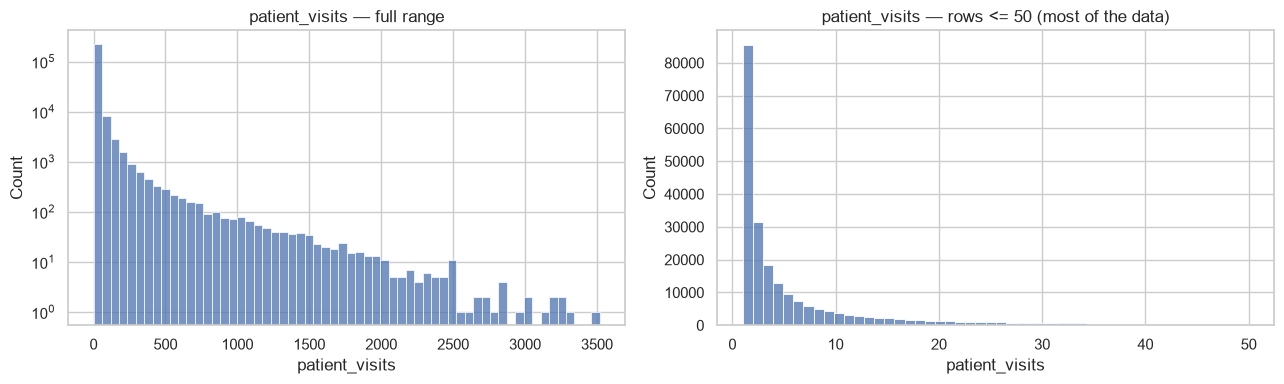

Skewness: 12.35
Kurtosis: 211.28


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(visits["patient_visits"], bins=60, ax=axes[0])
axes[0].set_title("patient_visits — full range")
axes[0].set_yscale("log")

sns.histplot(visits[visits["patient_visits"] <= 50]["patient_visits"], bins=50, ax=axes[1])
axes[1].set_title("patient_visits — rows <= 50 (most of the data)")

plt.tight_layout()
plt.show()

print(f"Skewness: {visits['patient_visits'].skew():.2f}")
print(f"Kurtosis: {visits['patient_visits'].kurt():.2f}")


**Finding:** `patient_visits` is heavily right-skewed, as expected for a count metric
spread across a huge combinatorial space (most month×product×specialty×age×gender
slices have only a handful of visits; a few common combinations have hundreds).


In [16]:
print("Categorical cardinality:")
for col in ["disease_area", "manufacturer", "product", "specialty", "age_band", "gender"]:
    print(f"  {col}: {visits[col].nunique()} distinct values")


Categorical cardinality:
  disease_area: 2 distinct values
  manufacturer: 173 distinct values
  product: 158 distinct values
  specialty: 50 distinct values
  age_band: 10 distinct values
  gender: 3 distinct values


In [17]:
top_products = visits.groupby("product")["patient_visits"].sum().sort_values(ascending=False)
print("Top 10 products by total visits:")
print(top_products.head(10))
print()
print("Bottom 10 products by total visits (the long tail):")
print(top_products.tail(10))


Top 10 products by total visits:
product
KENALOG                  1775156
DEPO-MEDROL              1102925
TRIAMCINOLONE ACTN        834658
BETAMETH ACE/SOD PHOS     399304
METHYLPRED ACE            390847
DEXAMETHASONE             166758
ASPIRIN                   151673
ZILRETTA                  135119
ACETAMINOPHEN             129477
CELESTONE                 111995
Name: patient_visits, dtype: int64

Bottom 10 products by total visits (the long tail):
product
DILAUDID SYRINGE        1
MLK PROCEDUR F2         1
PREDNISOLONE            1
ORENCIA                 1
OXYCODONE/APAP          1
MEDROLOAN SUIK          1
TAC-3                   1
STELARA                 1
READYSHARP ANES+KETO    1
TRUXIMA                 1
Name: patient_visits, dtype: int64


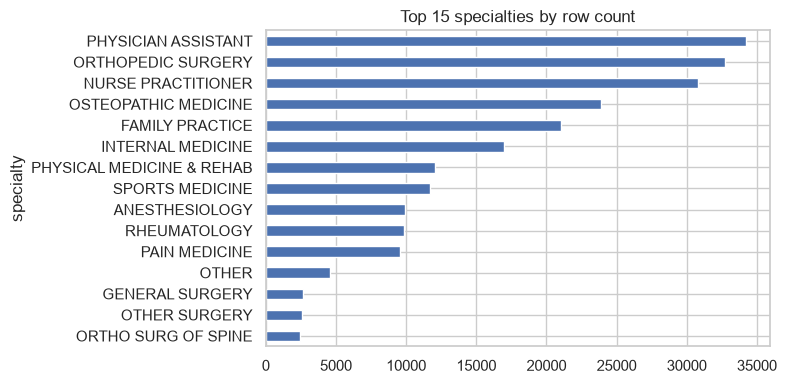

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
visits["specialty"].value_counts().head(15).plot(kind="barh", ax=ax)
ax.set_title("Top 15 specialties by row count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Step 5 — Outlier Detection

In [19]:
q1, q3 = visits["patient_visits"].quantile([0.25, 0.75])
iqr = q3 - q1
iqr_upper = q3 + 1.5 * iqr

z_scores = (visits["patient_visits"] - visits["patient_visits"].mean()) / visits["patient_visits"].std()

print(f"IQR upper fence: {iqr_upper:.1f}  -> rows above it: {(visits['patient_visits'] > iqr_upper).sum():,} ({(visits['patient_visits'] > iqr_upper).mean()*100:.1f}%)")
print(f"|z-score| > 3: {(z_scores.abs() > 3).sum():,} rows")
print()
print("Top 5 single highest rows (investigate, don't just flag):")
visits.nlargest(5, "patient_visits")[["month", "product", "specialty", "age_band", "gender", "patient_visits"]]


IQR upper fence: 23.5  -> rows above it: 34,037 (14.1%)
|z-score| > 3: 2,968 rows

Top 5 single highest rows (investigate, don't just flag):


,month,product,specialty,age_band,gender,patient_visits
105494,2022-06-01,KENALOG,ORTHOPEDIC SURGERY,65 TO 74,FEMALE,3519
112976,2022-08-01,KENALOG,ORTHOPEDIC SURGERY,65 TO 74,FEMALE,3326
116851,2022-09-01,KENALOG,ORTHOPEDIC SURGERY,65 TO 74,FEMALE,3267
146990,2023-05-01,KENALOG,ORTHOPEDIC SURGERY,65 TO 74,FEMALE,3260
120638,2022-10-01,KENALOG,ORTHOPEDIC SURGERY,65 TO 74,FEMALE,3204


**Interpretation:** a large fraction of rows technically clear the IQR fence, which
is the expected signature of a right-skewed count variable, not evidence of data
errors. The single highest rows are legitimate — a common generic product, in a
high-volume specialty, in a large age/gender bucket. **Decision: no rows removed** —
these are real, expected values, not anomalies to clean out.


## Step 6 — Bivariate / Multivariate Analysis

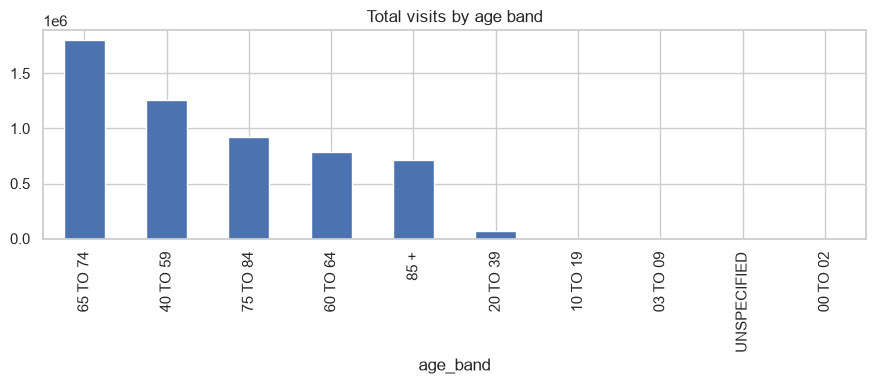

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
by_age = visits.groupby("age_band")["patient_visits"].sum().sort_values(ascending=False)
by_age.plot(kind="bar", ax=ax)
ax.set_title("Total visits by age band")
plt.tight_layout()
plt.show()


gender
FEMALE         3591431
MALE           1954038
UNSPECIFIED        621
Name: patient_visits, dtype: int64


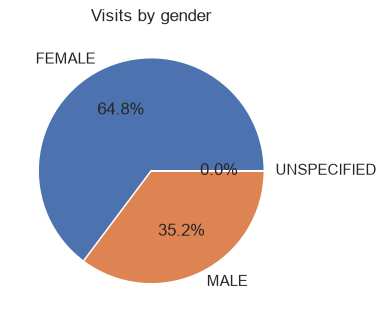

In [21]:
by_gender = visits.groupby("gender")["patient_visits"].sum()
print(by_gender)
by_gender.plot(kind="pie", autopct="%1.1f%%", figsize=(4, 4), title="Visits by gender")
plt.tight_layout()
plt.show()


In [22]:
# Categorical x categorical: brand_generic_tag vs disease_area, from the reference table
pd.crosstab(reference["brand_generic_tag"], reference["disease_area"])


disease_area,OA,RA
brand_generic_tag,,
BRAND,160,18
BRANDED GENERIC,88,0
GENERIC,340,0
OTHER,246,0


**Note on correlation:** there's little meaningful numeric-vs-numeric correlation at
this raw layer — `patient_visits` is the only numeric column, and the other fields
are all categorical dimensions describing *what kind* of visit it was, not competing
numeric measurements. Real correlation analysis (lag features, rolling averages,
FDA-derived features) belongs at the Gold-table stage, once those engineered numeric
columns exist — covered in the EDA-on-Gold-tables phase, not raw data.


## Step 7 — Time & Segment Analysis

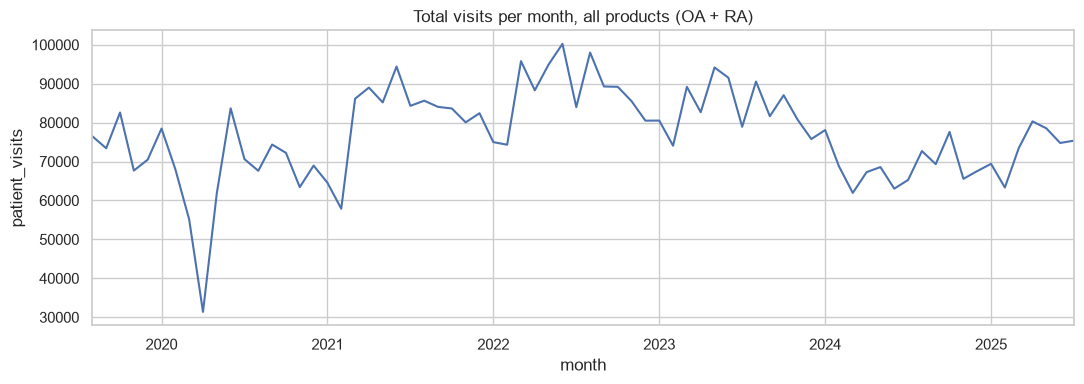

In [23]:
monthly_total = visits.groupby("month")["patient_visits"].sum().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))
monthly_total.plot(ax=ax)
ax.set_title("Total visits per month, all products (OA + RA)")
ax.set_ylabel("patient_visits")
plt.tight_layout()
plt.show()


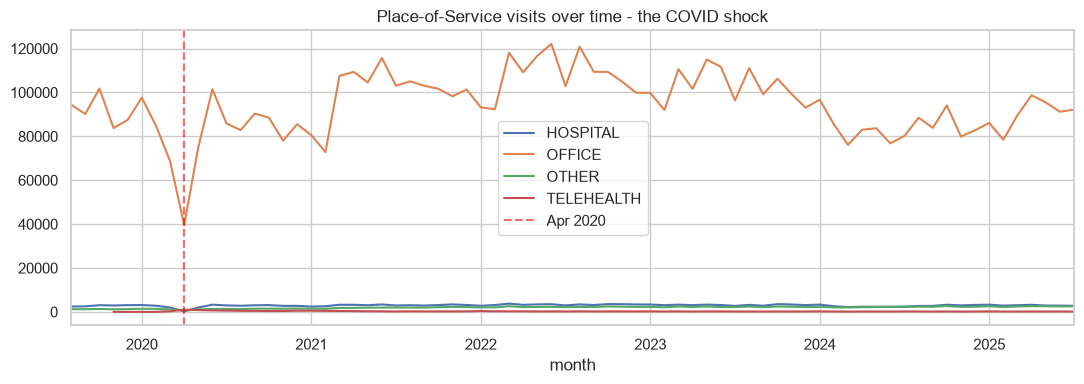

April 2020 vs March 2020:
place_of_service  HOSPITAL   OFFICE   OTHER  TELEHEALTH
month                                                  
2020-03-01          1977.0  68746.0  1102.0       275.0
2020-04-01           235.0  39488.0   629.0      1016.0


In [24]:
pos_pivot = pos.pivot_table(index="month", columns="place_of_service", values="patient_visits", aggfunc="sum")

fig, ax = plt.subplots(figsize=(11, 4))
pos_pivot.plot(ax=ax)
ax.set_title("Place-of-Service visits over time - the COVID shock")
ax.axvline(pd.Timestamp("2020-04-01"), color="red", linestyle="--", alpha=0.6, label="Apr 2020")
ax.legend()
plt.tight_layout()
plt.show()

print("April 2020 vs March 2020:")
print(pos_pivot.loc[["2020-03-01", "2020-04-01"]])


**Finding (confirms a Phase 2 discovery, now visualized):** Office visits collapse and
Telehealth spikes sharply in April 2020 — a real, dateable market shock, not a data
artifact. Any model needs to either explicitly flag this month or accept it as a
genuine outlier in the training window.


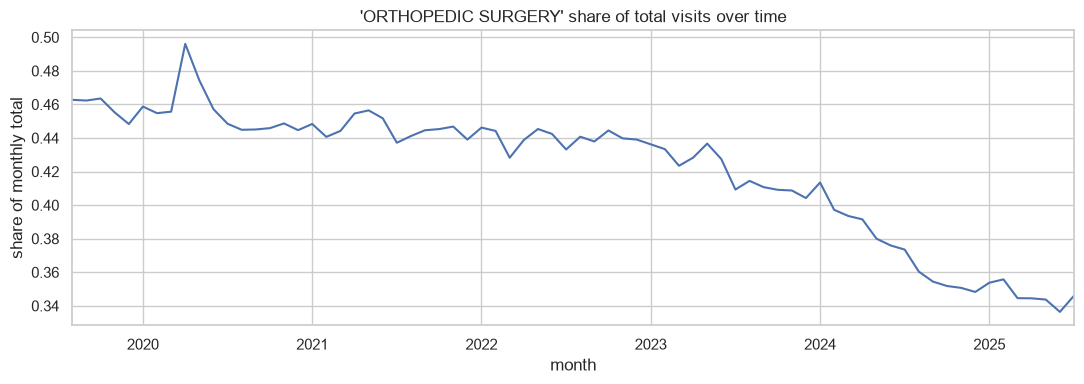

In [25]:
# Specialty-mix drift: has the top-specialty's share of total visits changed over time?
specialty_share = (
    visits.groupby(["month", "specialty"])["patient_visits"].sum()
    .groupby(level=0, group_keys=False).apply(lambda s: s / s.sum())
    .reset_index()
)
top_specialty = visits.groupby("specialty")["patient_visits"].sum().idxmax()
top_share_over_time = specialty_share[specialty_share["specialty"] == top_specialty].set_index("month")["patient_visits"]

fig, ax = plt.subplots(figsize=(11, 4))
top_share_over_time.plot(ax=ax)
ax.set_title(f"'{top_specialty}' share of total visits over time")
ax.set_ylabel("share of monthly total")
plt.tight_layout()
plt.show()


**Finding:** the top specialty's share of total visits does drift over the 6-year
window rather than staying flat — this is exactly the evidence behind the
"specialty-mix shift" feature flagged earlier as still missing from the Gold table.


## Step 8 — Feature-Level Insights

Concrete, decision-relevant findings from this notebook, several of which already
shaped real code in this project:

- **The naive (month, product, specialty, age, gender) key is not unique** — a
  product can appear under multiple manufacturers in one slice. `manufacturer` must
  be summed over, never used as a grouping key on its own — this is exactly what
  `build_silver.py`'s `refresh_fact_product_visits` does.
- **`manufacturer` itself is unreliable for identity** — the same product can carry
  different manufacturer labels over time (the Zilretta case) — informational
  display field only, confirmed here independently of the Phase 2 finding.
- **`patient_visits` is heavily right-skewed** — any model feature built directly
  from raw visit counts (rather than a share/ratio) should account for this, e.g. via
  a log transform, rather than assuming roughly-normal behavior.
- **The April 2020 COVID shock is real and needs explicit handling**, not generic
  seasonality smoothing.
- **Specialty mix genuinely drifts over time** — supports building the still-missing
  specialty-mix-shift feature for the classifier.
- **No missing values, no fully-duplicate rows, no invalid (non-positive) visit
  counts, no casing/whitespace inconsistencies** anywhere in the reshaped table —
  the raw IQVIA export is clean at the formatting level; the real complexity is
  entirely structural (the pivot shape, the manufacturer-key issue), not messy values.
- **2 reference-listed products (`SAPHNELO`, `DURACLON`) have zero actual visit rows**
  — legitimate, since `dim_product` is built from the reference file, not the fact
  data, but worth knowing before assuming every `dim_product` row is "active."


## Step 9 — Documented Findings & Decisions

| Finding | Decision | Where it's enforced |
|---|---|---|
| Raw sheet is 95.1% blank | Blank = zero visits, dropped rather than stored | `nmta_loader.py` |
| Row hierarchy only marked by cell indent | Read `cell.alignment.indent` directly, don't infer from values | `nmta_loader.py` |
| (month,product,specialty,age,gender) not a unique key | Sum across manufacturer to reach the true fact-table grain | `build_silver.py` |
| `manufacturer` unreliable for identity | Informational display field only, never used for grouping/joins | `schema.py`, `build_silver.py` |
| `patient_visits` heavily right-skewed | Note for future feature engineering — consider log/ratio transforms | Flagged here for Phase 3 |
| April 2020 COVID shock is real | Needs an explicit flag, not generic seasonality smoothing | Flagged in `data_analysis_reference.md` §4.1, not yet implemented as a model feature |
| Specialty mix drifts over time | Confirms the still-missing specialty-mix-shift feature is worth building | Flagged for Phase 3 feature engineering |
| No missing values / duplicates / invalid counts / casing issues in the reshaped table | No additional raw-value cleaning needed beyond what Phase 2 already does | — |
| `SAPHNELO`/`DURACLON` in `dim_product` but 0 rows in `fact_product_visits` | Expected — `dim_product` is built from the reference file, not fact data; no fix needed, just documented | Newly confirmed here against the live warehouse |

## Step 10 — Hand-off

**No upstream data-quality issues to fix** — the raw export is clean at the value
level; all real complexity is structural and already handled in the ingestion code.

**Feeds directly into:**
- The cleaning audit (confirms Phase 2's Pandera gate already covers what this
  notebook checked manually — missing values, invalid ranges, categorical domains)
- Phase 3 feature engineering: log/ratio transform consideration for visit-count-based
  features, the specialty-mix-shift feature, and an explicit COVID-month flag
- The next notebook in this sequence: EDA on the Gold tables, where the actual
  numeric time series (`visit_share`, lags, rolling averages) lives
